<a href="https://colab.research.google.com/github/Jorj91/Project_Explainable_AI_Banking_Model/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Interpretation of a Neural Network for Regulatory Compliance in Banking**


**Banca Virtuosa**, a leading institution in the financial sector, has identified the need to improve the transparency and interpretability of the artificial intelligence models used in its systems. To achieve this goal, Banca Virtuosa has launched a project aimed at implementing Explainable AI (XAI) techniques, in compliance with current regulations on banking transparency.

Currently, Banca Virtuosa uses pre-trained classification models to analyze and classify critical financial data. However, the lack of transparency in the decisions made by these models may undermine customer trust and limit the bank’s ability to improve its systems in a targeted way. Identifying and correcting classification errors is crucial to ensuring accuracy and reliability in the services offered.

<br>

##**Benefits of the Solution**

**1. Transparency in Model Decisions**

By implementing XAI techniques such as Grad-CAM, LIME, SHAP, Integrated Gradients, and Occlusion Maps, Banca Virtuosa will be able to generate saliency maps that visually show which elements influence the model’s decisions. This increase in transparency will improve the trust of customers and stakeholders, demonstrating the reliability and explainability of the classification system.

**2. Continuous Performance Improvement**

By analyzing saliency maps, Banca Virtuosa will be able to precisely identify the areas where the model makes mistakes, both in correct and incorrect classifications. This detailed analysis will enable targeted improvements to the model, optimizing its performance and reducing the risk of misinterpreting data.

**3. Regulatory Compliance**

The project will ensure that the decisions made by AI models are explainable and aligned with current regulatory requirements. Transparency in AI decisions is essential for regulatory compliance and corporate governance, especially in highly regulated sectors such as finance.

**4. Promotion of Innovation**

The adoption of advanced XAI techniques within Banca Virtuosa will promote innovation in artificial intelligence. This will strengthen the bank’s position as a pioneer in adopting advanced technologies, enabling it to offer customers increasingly sophisticated and reliable solutions.

<br>

##**Project Details**

**1. Phase 1: Use of a Pre-trained Classification Model**

- Model: Use a pre-trained model, such as DenseNet, from the torchvision library.

- Dataset: Apply the model to an image dataset, such as MNIST, to explore its classification decisions.

**2. Phase 2: Generation of Saliency Maps**

- XAI Techniques: Implement techniques such as Grad-CAM, LIME, SHAP, Integrated Gradients, and Occlusion Maps to generate saliency maps of the model.

**3. Phase 3: Final Report**
- Dataset Description: detail the origin, structure, and characteristics of the dataset used.

- Saliency Map Analysis: compare saliency maps for correctly classified and misclassified classes in order to identify and understand model errors.

- Explainable System (Optional): describe a fully explainable system that could perform the same classification task, providing additional insights into the model’s decision-making process.

<br>

##**Project Objectives**

**1. Model Understanding**
Use XAI techniques to gain a deep understanding of the internal functioning of the pre-trained model.

**2. Decision Visualization**
Clearly and interpretably visualize which elements influence the model’s decisions through saliency maps.

**3. Error Identification**
Analyze saliency maps to identify and understand model errors, distinguishing between correct and incorrect classifications.

**4. Creation of Explainable Systems**
If possible, develop or describe a fully explainable system capable of performing the same classification task, providing further insight into the model’s decisions.

<br>

##**Project Motivation**

Explainable AI techniques are essential for Banca Virtuosa to improve transparency, optimize model performance, and ensure regulatory compliance. Through this project, the bank aims to strengthen customer trust, improve operational efficiency, and promote innovation in the field of artificial intelligence.

-------------------------

# Environment Setup

In [1]:
import os

# clone repo
repo_name = "Project_Explainable_AI_Banking_Model"
repo_path = f"/content/{repo_name}"

# go to root
os.chdir("/content")

if not os.path.exists(repo_path):
    !git clone https://github.com/Jorj91/Project_Explainable_AI_Banking_Model.git
else:
    print("Repo already exists ✔")

# move into repo folder
os.chdir(repo_path)
print("Current directory:", os.getcwd())

Repo already exists ✔
Current directory: /content/Project_Explainable_AI_Banking_Model


## Installation

In [2]:
# Install project dependencies (only if needed)

import importlib

if importlib.util.find_spec("captum") is None:
    !pip install -r requirements.txt -q
    !pip install kaggle -q
    print("Dependencies installed")
    print("Please restart runtime, then run ALL cells again from the top")
else:
    print("Dependencies already installed ✔")

Dependencies already installed ✔


## Dataset

We use the CEDAR signature dataset from Kaggle, which contains genuine and forged handwritten signatures labeled for binary classification. This dataset reflects a realistic banking scenario such as verifying signatures on contracts, payment authorizations, or identity documents.

In this project, the model predicts whether a signature is genuine or forged, while XAI techniques highlight the regions influencing the decision. This supports banking requirements for transparency, fraud detection, error analysis, and regulatory compliance by making automated verification decisions explainable.

In [3]:
# Kaggle setup

# Upload kaggle.json only if not already configured
if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please upload your kaggle.json file")

    from google.colab import files
    files.upload()

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    print("Kaggle configured ✔")
else:
    print("Kaggle already configured ✔")


Please upload your kaggle.json file


Saving kaggle.json to kaggle.json
Kaggle configured ✔


In [ ]:
# # FOR RUNNING IN LOCAL VS CODE
# ! pip install -r requirements.txt -q

In [4]:
import sys
import os
sys.path.append(os.path.abspath("src"))

In [5]:
# import data module
import src.data as data
import importlib
importlib.reload(data)

<module 'src.data' from '/content/Project_Explainable_AI_Banking_Model/src/data.py'>

In [6]:
# dataset download
data.download_and_extract_dataset()

Extracting dataset...
Dataset ready at: /content/Project_Explainable_AI_Banking_Model/data


## Imports

In [7]:
# Core
import numpy as np
import pandas as pd
import random
import shutil
import zipfile
from pathlib import Path
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch (deep learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import ImageFolder

# Image processing
import cv2
from PIL import Image

# ML utils
from sklearn.model_selection import train_test_split

# Explainable AI (XAI)

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
# Captum
from captum.attr import IntegratedGradients, Occlusion
# LIME
from lime import lime_image
from skimage.segmentation import mark_boundaries
# SHAP
import shap

# Explainable System (Interpretable Model)
from skimage.morphology import skeletonize
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text
from sklearn import tree

print("Environment ready ✔")

Environment ready ✔


# EDA & Data Preparation

In [8]:
# Load and inspect images for a single writer (signatures_1)
files, genuine, forged = data.get_image_files("data/signatures/signatures_1")

# Show counts for this writer
print("Total images:", len(files))
print("Genuine:", len(genuine))
print("Forged:", len(forged))

Total images: 48
Genuine: 24
Forged: 24


In [9]:
# Show number of writers in the dataset
writers = data.get_writers()
print("Number of Writers:", len(writers))

Number of Writers: 55


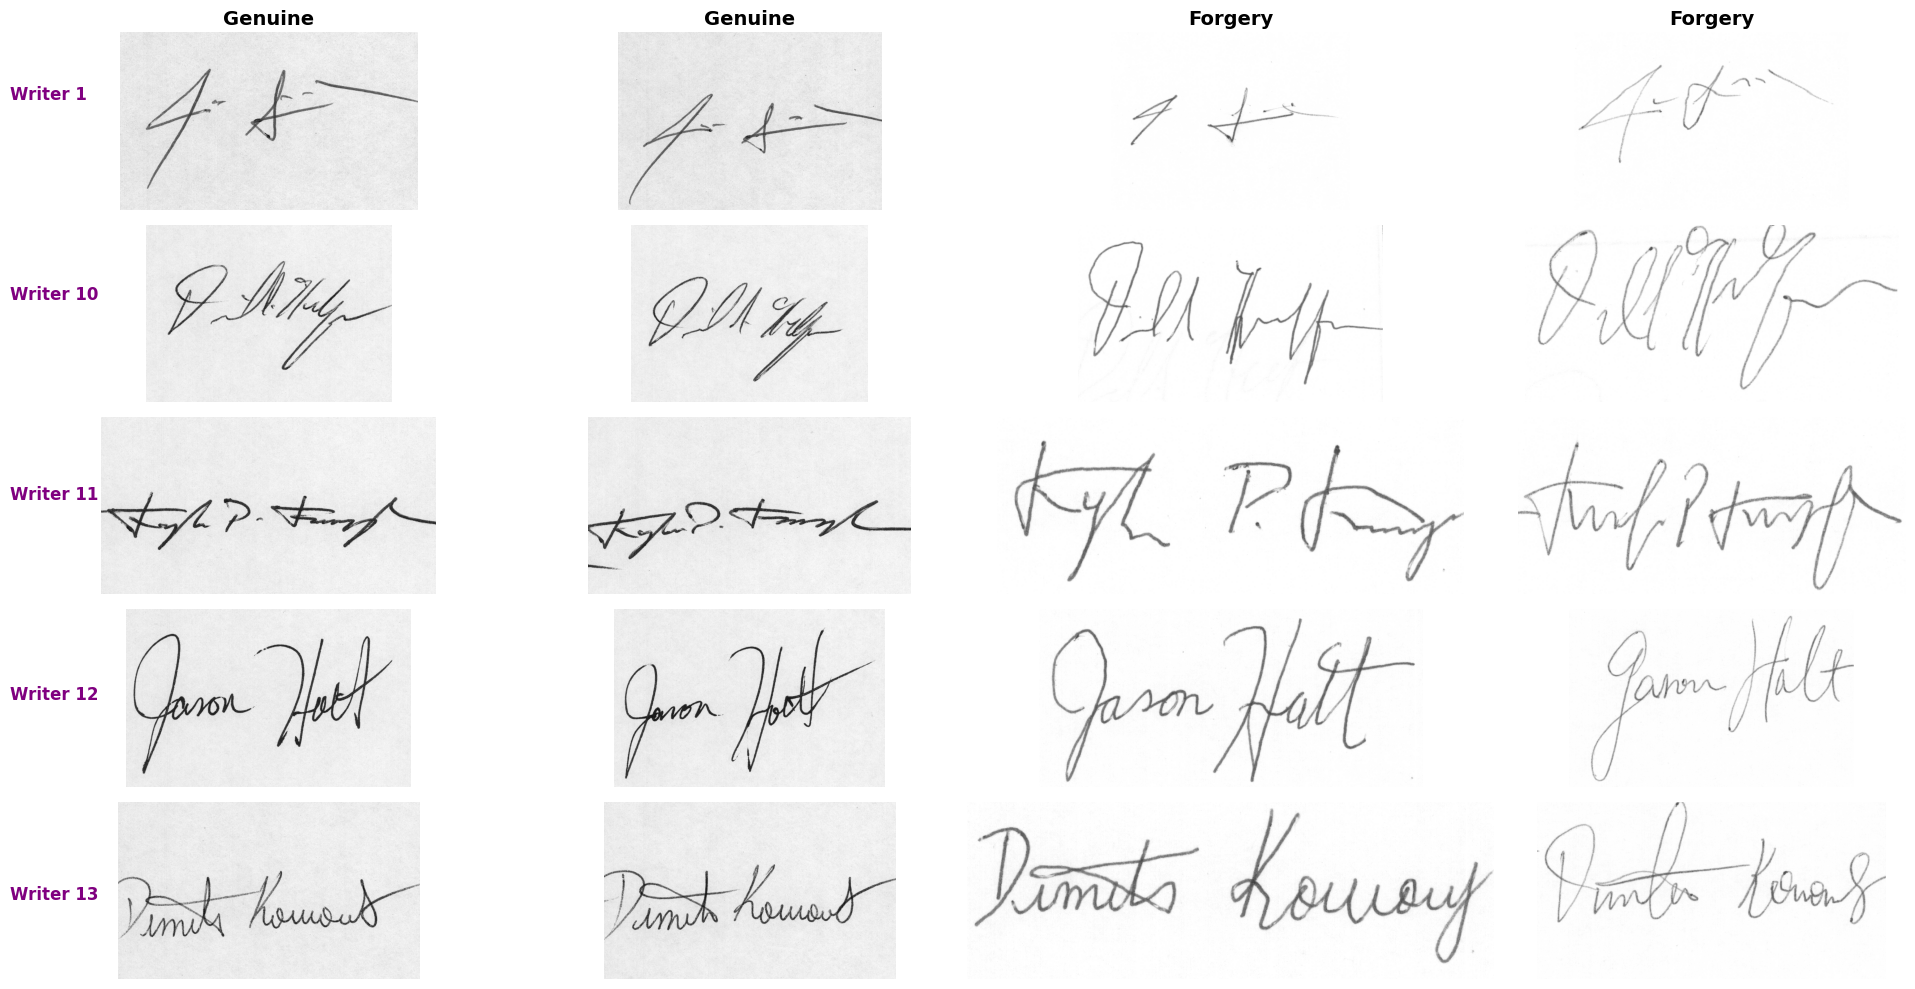

In [10]:
# Visualize sample signatures for multiple writers.
# For each writer, display 2 genuine signatures and 2 forged signatures

root = Path("data/signatures")

# Get 5 writers (random or first 5)
writers_plot = sorted(root.glob("signatures_*"))[:5]

fig, axes = plt.subplots(len(writers_plot), 4, figsize=(20, 10))

for i, writer in enumerate(writers_plot):

    # Get images
    genuine_imgs = sorted([p for p in writer.glob("*.png") if "original" in p.name.lower()])[:2]
    forged_imgs = sorted([p for p in writer.glob("*.png") if "forgeries" in p.name.lower()])[:2]

    # Combine (2 genuine + 2 forged)
    selected_imgs = genuine_imgs + forged_imgs

    for j, img_path in enumerate(selected_imgs):
        img = Image.open(img_path)

        axes[i, j].imshow(img, cmap="gray")
        axes[i, j].axis("off")

        # Titles only on first row
        if i == 0:
            if j < 2:
                axes[i, j].set_title("Genuine",
                                     fontsize=14,
                                     fontweight="bold")
            else:
                axes[i, j].set_title("Forgery",
                                     fontsize=14,
                                     fontweight="bold")

# Create space on the left for writer labels
plt.subplots_adjust(left=0.02)

# Add writer labels (outside plots)
for i, writer in enumerate(writers_plot):
    writer_id = writer.name.split("_")[-1]
    fig.text(
        0.01,                         # left margin
        1 - (i + 0.5) / len(writers_plot), # vertical position per row
        f"Writer {writer_id}",
        va="center",
        fontsize=12,
        fontweight = "bold",
        color = "purple"
    )


plt.tight_layout()
plt.show()

Genuine signatures (left) show high consistency in shape and stroke patterns for each writer.  
Forged signatures (right) display differences in stroke smoothness and pressure greater variability, with less precise replication and noticeable distortions.

This suggests that the task relies on capturing subtle, fine-grained differences between genuine and forged samples.

In [11]:
# Subject-level data split

# The split_writers function divides the list of writers into
# training, validation, and test sets.
# - Writers are first shuffled using a fixed seed for reproducibility.
# - The split follows the proportions: 70% train, 15% validation, 15% test.
# - The split is done at writer level to avoid data leakage between sets.

train_writers, val_writers, test_writers = data.split_writers(writers)

In [12]:
# Save the split

split = {
    "train": [str(p) for p in train_writers],
    "val": [str(p) for p in val_writers],
    "test": [str(p) for p in test_writers]
}

Path("results/split").mkdir(exist_ok=True)

with open("results/split/split.json", "w") as f:
    json.dump(split, f, indent=2)

In [13]:
# download split (Colab only!)
from google.colab import files
files.download("results/split/split.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# load the split
with open("results/split/split.json") as f:
    split = json.load(f)

train_writers = [Path(p) for p in split["train"]]
val_writers = [Path(p) for p in split["val"]]
test_writers = [Path(p) for p in split["test"]]

In [15]:
# Create Folder Structure

# This function creates the directory structure required for the dataset splits.
# - Generates separate folders for each split: train, validation, and test.
# - Within each split, creates class subfolders: "genuine" and "forged".

data.create_split_folders()

Folder structure created (clean)


In [16]:
# copy images into splits
base = Path("data")

data.copy_images(train_writers, "train", base)
data.copy_images(val_writers, "val", base)
data.copy_images(test_writers, "test", base)

print(f"Dataset split completed at: {base.resolve()}")


Dataset split completed at: /content/Project_Explainable_AI_Banking_Model/data



**Dataset Statistics Overview**

This function quick_stats() computes and visualizes basic statistics and quick EDA of CEDAR dataset.

- Iterates through all writer folders and counts genuine ("original") and forged signatures.
- Prints a summary of dataset statistics (total, genuine, forged).

Displays:

• A pie chart showing the overall distribution of genuine vs forged signatures.

• A stacked bar plot showing the number of signatures per writer.



📊 Dataset Statistics
------------------------------
Total images: 2640
Genuine:     1320
Forged:       1320





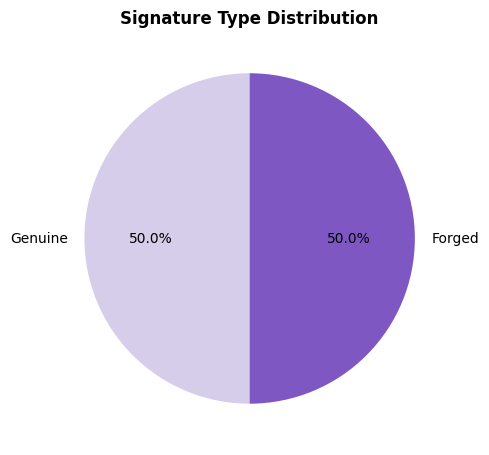

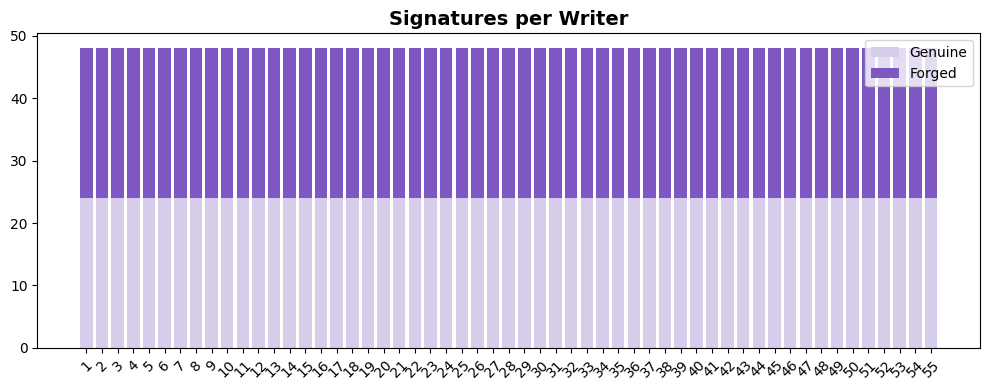

In [17]:
# dataset overview
data.quick_stats()



As we can see from the results above, the dataset is perfectly balanced, with 1320 genuine and 1320 forged signatures (50% each).  
This class balance is also consistent across writers, as each writer contributes an equal number of genuine and forged samples.

Such a balanced distribution is ideal for training, as it prevents bias toward one class and allows the model to learn both classes equally.

In [18]:
# dataset splits statistics
def count_images(path):
    return len(list(path.glob("*.png")))

base = Path("data")

for split in ["train", "val", "test"]:

    g = count_images(base / split / "genuine")
    f = count_images(base / split / "forged")

    print(split, "genuine:", g, "forged:", f, "total:", g+f)

train genuine: 912 forged: 912 total: 1824
val genuine: 192 forged: 192 total: 384
test genuine: 216 forged: 216 total: 432


# DataLoaders

In this section, the dataset is prepared for training, validation, and testing:

- **Image transformations** are defined to standardize the input:
  - All images are resized to 224×224 and converted to 3-channel grayscale.
  - Data augmentation (random rotation and affine transformations) is applied only to the training set to improve generalization.
  - Images are converted to tensors and normalized.

- **Datasets** are created using `ImageFolder`, which organizes images based on the directory structure (`train/`, `val/`, `test/`) and automatically assigns labels (`genuine`, `forged`).

- **Dataloaders** are built to load the data in mini-batches (batch size = 32), enabling efficient training and evaluation. Shuffling is applied only to the training set.

In [19]:
from src.data import get_transforms, get_datasets, get_dataloaders

# get transforms
train_transform, test_transform = get_transforms()

# create datasets
train_dataset, val_dataset, test_dataset = get_datasets(train_transform, test_transform)

# Create dataloaders from datasets
train_loader, val_loader, test_loader = get_dataloaders(train_dataset, val_dataset, test_dataset)

In [20]:
# verify label assignment.
print("\n📊 Class to Index Mapping\n")
print("Train:", train_dataset.class_to_idx)
print("Val:", val_dataset.class_to_idx)
print("Test:", test_dataset.class_to_idx)


📊 Class to Index Mapping

Train: {'forged': 0, 'genuine': 1}
Val: {'forged': 0, 'genuine': 1}
Test: {'forged': 0, 'genuine': 1}


# DenseNet: Pre-trained Classification Model

In [21]:
# Reload custom training module to reflect latest changes (useful during development)
import src.train
importlib.reload(src.train)

<module 'src.train' from '/content/Project_Explainable_AI_Banking_Model/src/train.py'>

In [22]:
# Import modular components
from src.model import get_model
from src.train import (
    get_device,
    get_criterion,
    get_optimizer,
    train_model,
    evaluate,
    load_model
)

In [23]:
# Initialize Model and Training Components

# Model init: Create DenseNet-based model with custom classifier

# get_model function creates a DenseNet-121 model for classification by:

# - Loading a pretrained backbone (optional)
# - Freezing feature layers (optional)
# - Replacing the classifier with a custom layer for the target classes

# This setup is commonly used for transfer learning, where a pretrained model is fine-tuned on a new dataset.

model = get_model()

# device setup: Use GPU if available, otherwise fallback to CPU
device = get_device()
model = model.to(device)

# Loss and Optimizer
# CrossEntropyLoss → for classification
# Adam optimizer → adaptive learning rate
criterion = get_criterion()
optimizer = get_optimizer(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 70.1MB/s]


# Training & Evaluation

## Training Loop

This section trains the model and evaluates its performance:

- The model is trained for multiple epochs using training data, while monitoring validation performance each epoch
- Early stopping halts training if validation accuracy stops improving
- The best model (highest validation accuracy) is saved during training

After training:

- The best saved model is reloaded
- Final performance is evaluated on the unseen test set

This ensures results are based on the most generalizable model, not just the last training epoch.

In [24]:
# =========================
# 🚀 TRAIN MODEL
# =========================

# Train model with:
# - Early stopping (patience=3)
# - Best model checkpoint saving
# - Validation monitoring each epoch

train_model(
    model,
    train_loader, # batched training data
    val_loader, # validation set for generalization check
    criterion,
    optimizer,
    device,
    epochs=10,
    patience=3,
    save_path="results/models/densenet_best.pth"
)


# =========================
# 📈 TEST EVALUATION
# =========================

# Reload BEST model before testing

# Reload the BEST model (based on validation accuracy)
# This ensures we evaluate the optimal checkpoint, not the last epoch

model = load_model(
    model,
    "results/models/densenet_best.pth",
    device
)

model.eval()

# Evaluate on unseen test data
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"\nTest Accuracy: {test_acc:.4f}")


Epoch 1
Train Loss: 0.7326 | Train Acc: 0.5329
Val Loss: 0.6410 | Val Acc: 0.6250

Epoch 2
Train Loss: 0.6659 | Train Acc: 0.6009
Val Loss: 0.5818 | Val Acc: 0.7839

Epoch 3
Train Loss: 0.6097 | Train Acc: 0.6645
Val Loss: 0.5288 | Val Acc: 0.8620

Epoch 4
Train Loss: 0.5666 | Train Acc: 0.7198
Val Loss: 0.4857 | Val Acc: 0.8932

Epoch 5
Train Loss: 0.5126 | Train Acc: 0.7577
Val Loss: 0.4465 | Val Acc: 0.9167

Epoch 6
Train Loss: 0.4967 | Train Acc: 0.7730
Val Loss: 0.4247 | Val Acc: 0.9089
⏳ No improvement (1/3)

Epoch 7
Train Loss: 0.4713 | Train Acc: 0.7884
Val Loss: 0.3906 | Val Acc: 0.9401

Epoch 8
Train Loss: 0.4371 | Train Acc: 0.8284
Val Loss: 0.3742 | Val Acc: 0.9427

Epoch 9
Train Loss: 0.4317 | Train Acc: 0.8196
Val Loss: 0.3503 | Val Acc: 0.9401
⏳ No improvement (1/3)

Epoch 10
Train Loss: 0.4090 | Train Acc: 0.8416
Val Loss: 0.3433 | Val Acc: 0.9453

Training completed. 
Best Validation Accuracy: 0.9453

✅ Best model saved at: results/models/densenet_best.pth

Test Accur

<br>

**Training Results Interpretation**


* **Steady learning:** Training loss decreases and accuracy improves across epochs → the model is learning meaningful patterns

* **Strong validation performance:** Validation accuracy steadily increases, reaching approximately 94.5%,  indicating good generalization

* **Early stopping behavior:** Although early stopping was enabled, validation performance continued improving until the final epochs, suggesting stable learning without strong overfitting.

* **Small train–val gap:** Validation accuracy is higher than training accuracy, likely due to:

  * Data augmentation applied only during training, making training samples harder
  * Regularization (dropout) making training harder

* **Test performance:** Final test accuracy (94.9%) is consistent with validation performance, confirming that the model generalizes well to unseen data.

Overall, the model shows **stable learning, strong generalization with no significant signs of overfitting**.


## Confusion Matrix

In [25]:
import src.evaluation as evaluation
import importlib
importlib.reload(evaluation)

from src.evaluation import plot_confusion_matrix

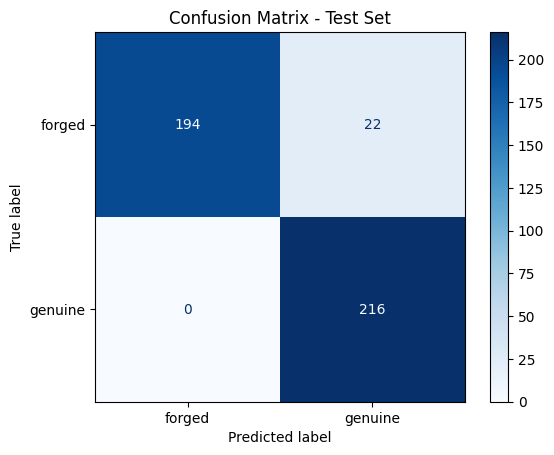

array([[194,  22],
       [  0, 216]])

In [26]:
plot_confusion_matrix(model, test_loader, device)

The confusion matrix shows strong performance, with 410 correct predictions out of 432 (94.9% accuracy). All 216 genuine signatures are correctly classified, while 22 forged signatures are misclassified as genuine.

This indicates a slight bias toward predicting the genuine class. The model avoids rejecting legitimate signatures but occasionally accepts forged ones. As a result, the system prioritizes customer convenience while slightly increasing fraud risk due to a small number of false positives.

In [27]:
# download model (Colab only!)

# Download model checkpoint from Colab to local machine
from google.colab import files
files.download("results/models/densenet_best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Explainable AI (XAI)

## Model Agnostic Method

### LIME

In this section, the best trained DenseNet model is reloaded and used to analyze representative predictions from the test set.

One example is selected for each scenario (correct genuine, correct forged, false positive, and false negative). LIME is then applied to generate saliency maps that highlight the image regions most influencing the model’s decisions. LIME works by perturbing superpixel regions of the image and observing how the model’s prediction changes, allowing identification of the areas that contribute most to the predicted class.

In [28]:
# LOAD BEST TRAINED MODEL FOR XAI ANALYSIS

# Rebuild model for loading

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# recreate exact model architecture (weights=None cause we'll load OUR trained weigths later)
model = models.densenet121(weights=None)

# Rebuild classifier to match training setup
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.classifier.in_features, 2)
)

# Load trained weigths
checkpoint = torch.load(
    "results/models/densenet_best.pth",
    map_location=device
)

# Load weights into model
model.load_state_dict(checkpoint["model_state"])

model = model.to(device)

model.eval()

# checkpoint info
print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"Best validation accuracy: {checkpoint['best_val_acc']:.4f}")

Loaded model from epoch 10
Best validation accuracy: 0.9453


In [29]:
# Select representative examples for XAI

# We collect one example for each case:
# - correct genuine prediction
# - correct forged prediction
# - false positive (forged → genuine)
# - false negative (genuine → forged)

cases = {
    "correct_genuine": None,
    "correct_forged": None,
    "false_positive": None,
    "false_negative": None
}

# Iterate through test dataset to find examples
for img, label in test_dataset:

    # Add batch dimension and move to device
    input_tensor = img.unsqueeze(0).to(device)
    # Model prediction
    with torch.no_grad():
        output = model(input_tensor)
    # Predicted class
    pred = torch.argmax(output,1).item()
    # Prediction confidence (softmax probability)
    probs = torch.softmax(output, dim=1)
    confidence = probs[0, pred].item()

    # forged = 0 | genuine = 1

    # Correct forged
    if label == 0 and pred == 0 and cases["correct_forged"] is None:
        cases["correct_forged"] = (img, label, pred, confidence)
    # Correct genuine
    elif label == 1 and pred == 1 and cases["correct_genuine"] is None:
        cases["correct_genuine"] = (img, label, pred, confidence)
    # False positive: forged predicted as genuine
    elif label == 0 and pred == 1 and cases["false_positive"] is None:
        cases["false_positive"] = (img, label, pred, confidence)
    # False negative: genuine predicted as forged
    elif label == 1 and pred == 0 and cases["false_negative"] is None:
        cases["false_negative"] = (img, label, pred, confidence)

    # Stop once all cases are found
    if all(v is not None for v in cases.values()):
        break

In [30]:
cases['correct_genuine']

(tensor([[[0.8824, 0.8824, 0.8745,  ..., 0.8902, 0.9059, 0.9059],
          [0.8824, 0.8667, 0.8745,  ..., 0.8980, 0.8980, 0.8824],
          [0.8745, 0.8824, 0.8588,  ..., 0.9137, 0.8902, 0.8745],
          ...,
          [0.8902, 0.8824, 0.8745,  ..., 0.8902, 0.8745, 0.8745],
          [0.8980, 0.8980, 0.8980,  ..., 0.8745, 0.8824, 0.8902],
          [0.8902, 0.8980, 0.8980,  ..., 0.8745, 0.8745, 0.8824]],
 
         [[0.8824, 0.8824, 0.8745,  ..., 0.8902, 0.9059, 0.9059],
          [0.8824, 0.8667, 0.8745,  ..., 0.8980, 0.8980, 0.8824],
          [0.8745, 0.8824, 0.8588,  ..., 0.9137, 0.8902, 0.8745],
          ...,
          [0.8902, 0.8824, 0.8745,  ..., 0.8902, 0.8745, 0.8745],
          [0.8980, 0.8980, 0.8980,  ..., 0.8745, 0.8824, 0.8902],
          [0.8902, 0.8980, 0.8980,  ..., 0.8745, 0.8745, 0.8824]],
 
         [[0.8824, 0.8824, 0.8745,  ..., 0.8902, 0.9059, 0.9059],
          [0.8824, 0.8667, 0.8745,  ..., 0.8980, 0.8980, 0.8824],
          [0.8745, 0.8824, 0.8588,  ...,

In [31]:
for k,v in cases.items():
    print(k, "FOUND" if v is not None else "NOT FOUND")

correct_genuine FOUND
correct_forged FOUND
false_positive FOUND
false_negative NOT FOUND


In [32]:
# save cases in pytorch binary format pt
os.makedirs("results/cases", exist_ok=True)
torch.save(cases, "results/cases/cases.pt")
# download cases (for colab only!)
files.download("results/cases/cases.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# reload cases
cases = torch.load("results/cases/cases.pt")

In [34]:
import importlib
import src.explainability

importlib.reload(src.explainability)

from src.explainability import denormalize

# Utility function for XAI visualization:
# denormalize: converts normalized tensors into original grayscale images

In [35]:
# Prediction Function for LIME

# LIME requires a prediction function that:
# - receives images as numpy arrays
# - returns class probabilities

def predict_fn(images):

    model.eval()
    # Convert numpy images [N,H,W,C] → tensor [N,C,H,W]
    images = torch.tensor(images).permute(0,3,1,2).float()

    # normalize (same as training)
    images = (images - 0.5) / 0.5

    images = images.to(device)

    # Forward pass
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

In [36]:
# Initialize LIME image explainer
lime_explainer = lime_image.LimeImageExplainer(random_state=42)

In [37]:
# Keep only cases that were found
found_cases = [c for c in cases if cases[c] is not None]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

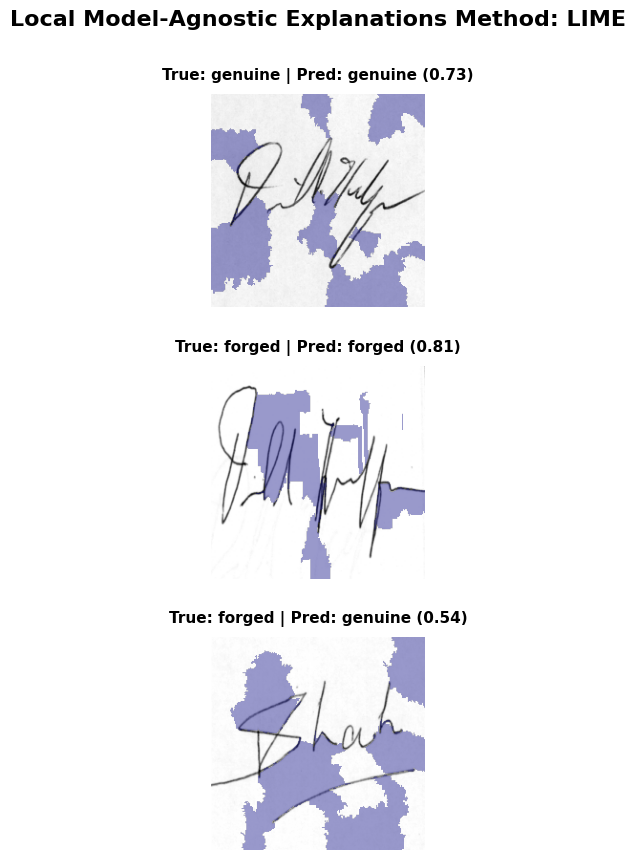

In [38]:
# =========================
# LIME VISUALIZATION
# =========================

# Create one row per case
fig, axes = plt.subplots(len(found_cases), 1, figsize=(4, 3*len(found_cases)))

fig.suptitle(
    "Local Model-Agnostic Explanations Method: LIME",
    fontsize=16,
    fontweight="bold",
    y=0.95
)

# Ensure axes is iterable when only one case exists
if len(found_cases) == 1:
    axes = [axes]

class_names = test_dataset.classes
TITLE_STYLE = dict(fontsize=11, fontweight="bold", pad=10)

# Loop over selected cases
for row, case in enumerate(found_cases):

    img, label, pred, confidence = cases[case]

    # denormalize
    img_np = denormalize(img)

    # Generate LIME explanation
    explanation = lime_explainer.explain_instance(
        img_np,         # image to explain
        predict_fn,     # prediction function
        top_labels=1,   # explain predicted class
        hide_color=0,   # masked region color
        num_samples=500 # number of perturbations
    )

    # Extract most important superpixels
    temp, mask = explanation.get_image_and_mask(
        label=pred,     # class to explain
        positive_only=True, # show positive contributions only
        num_features=10,  # number of highlighted regions
        hide_rest=False
    )

    true_label = class_names[label]
    pred_label = class_names[pred]

    # grayscale background
    axes[row].imshow(img_np[:,:,0], cmap="gray")

    # Overlay important regions (LIME mask)
    axes[row].imshow(
        np.ma.masked_where(mask == 0, mask),
        cmap="jet",
        alpha=0.4
    )

    axes[row].set_title(
        f"\nTrue: {true_label} | Pred: {pred_label} ({confidence:.2f})",
        **TITLE_STYLE
    )
    axes[row].axis("off")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

The LIME explanations highlight superpixel regions that most influence the model’s predictions and provide a model-agnostic view of the decision process.

In correctly classified examples, the highlighted regions largely overlap with the signature strokes and their structural components, indicating that the model relies on meaningful geometric patterns such as stroke continuity, curvature, and spacing. Some background areas are also selected, which is expected with LIME’s superpixel-based perturbation strategy, but the dominant focus remains on the signature. For correctly identified forged signatures, the highlighted regions concentrate on central stroke segments and intersections, suggesting the model captures local irregularities typical of forged writing.

In contrast, misclassified examples show less coherent attention. In the false positive case, highlighted regions are fragmented and partially located around the signature rather than along the main stroke trajectory, indicating reliance on weaker discriminative features.

Overall, the LIME results indicate that the model generally focuses on relevant signature structures but occasionally shifts attention to less informative regions, leading to incorrect predictions.

## Attribution Methods

### Local GradCAM, Integrated Gradients, Occlusion and SHAP

In this section, multiple attribution methods are applied to the selected examples in order to compare how different techniques explain the model’s predictions.

Grad-CAM highlights important spatial regions using activations from the last convolutional layer, Integrated Gradients computes feature attributions by accumulating gradients along an interpolation path, Occlusion measures prediction changes when parts of the image are masked, and SHAP estimates feature importance using background-based gradient explanations.

The resulting attribution maps are normalized and overlaid on the original images for side-by-side comparison across methods.

In [39]:
import importlib
import src.explainability

importlib.reload(src.explainability)

from src.explainability import (
    denormalize,
    normalize_map,
    visualize_attr_map
)

# Utility functions for XAI visualization:
# denormalize: converts normalized tensors into original grayscale images
# normalize_map: scales attribution maps to [0,1] for consistent visualization
# visualize_attr_map: overlays attribution heatmaps on the input image

In [40]:
# SETUP XAI METHODS

# last convolutional block of DenseNet121 for Grad-CAM
target_layer = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

# initialize gradient-based attribution methods: IG and Occlusion
ig = IntegratedGradients(model)
occlusion = Occlusion(model)

In [41]:
# SHAP SETUP

# Select background samples from training data (required by SHAP)
background, _ = next(iter(train_loader))
# use subset for speed
background = background[:100].to(device)

Path("results/background").mkdir(parents=True, exist_ok=True)
torch.save(background, "results/background/shap_background.pt")

In [42]:
# download background (for colab only!)
files.download("results/background/shap_background.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
background = torch.load("results/background/shap_background.pt")
background = background.to(device)

# Initialize SHAP GradientExplainer
shap_explainer = shap.GradientExplainer(model, background)

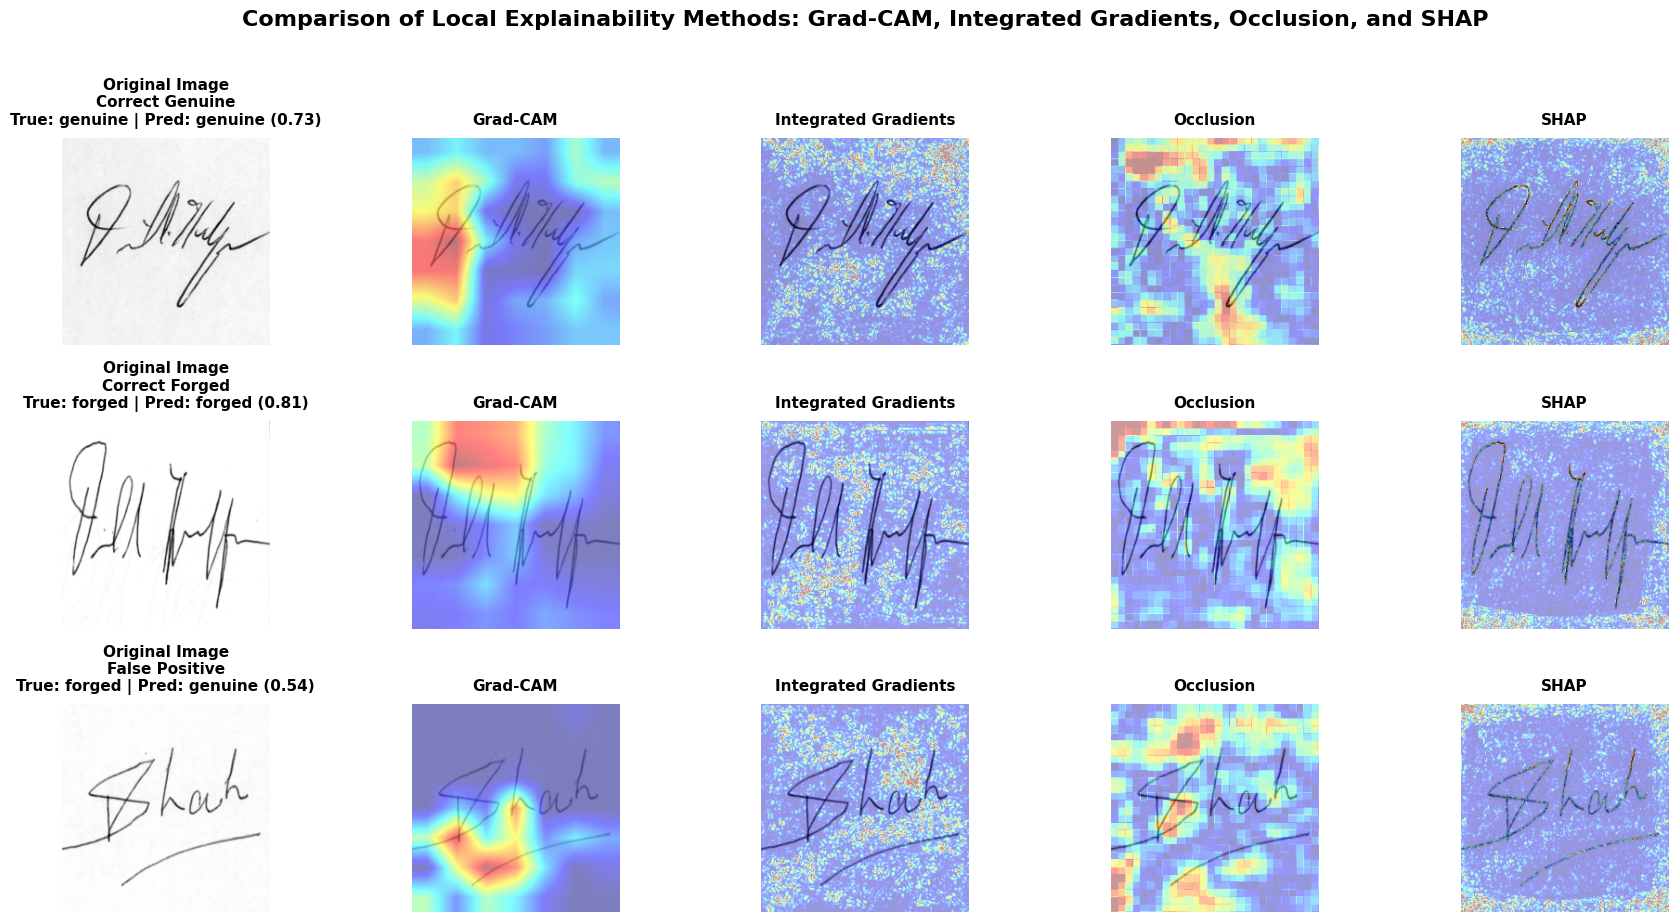

In [44]:
# VISUALIZATION

# Create figure:
# rows = selected cases
# columns = Original | GradCAM | IG | Occlusion | SHAP
fig, axes = plt.subplots(len(found_cases), 5, figsize=(18, 3*len(found_cases)))

fig.suptitle(
    "Comparison of Local Explainability Methods: Grad-CAM, Integrated Gradients, Occlusion, and SHAP",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

if len(found_cases) == 1:
    axes = axes.reshape(1, -1)

class_names = test_dataset.classes

TITLE_STYLE = dict(fontsize=11, fontweight="bold", pad=10)

for row, case in enumerate(found_cases):

    img, label, pred, confidence = cases[case]
    input_tensor = img.unsqueeze(0).to(device)

    true_label = class_names[label]
    pred_label = class_names[pred]

    # Convert tensor to displayable image
    rgb_img = denormalize(img)

    # ------------------
    # 1. ORIGINAL IMAGE
    # ------------------
    axes[row,0].imshow(rgb_img[:,:,0], cmap='gray')
    axes[row,0].set_title(
    f"Original Image\n{case.replace('_',' ').title()}\n"
    f"True: {true_label} | Pred: {pred_label} ({confidence:.2f})",
    **TITLE_STYLE)

    axes[row,0].axis("off")

    # ------------------
    # 2. GRAD-CAM
    # ------------------
    # Target predicted class
    targets = [ClassifierOutputTarget(pred)]
    # Compute Grad-CAM heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    # # Overlay heatmap on image
    gradcam_vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    axes[row,1].imshow(gradcam_vis)
    axes[row,1].set_title("Grad-CAM", **TITLE_STYLE)
    axes[row,1].axis("off")

    # ------------------
    # 3. INTEGRATED GRADIENTS
    # ------------------
    # Enable gradients for input
    input_tensor_ig = input_tensor.clone().detach().requires_grad_(True)
    #Compute IG attribution
    ig_attr = ig.attribute(
        input_tensor_ig,
        target=pred,
        n_steps=50
    )

    visualize_attr_map(img, ig_attr, "Integrated Gradients", axes[row,2], TITLE_STYLE)

    # ------------------
    # 4. OCCLUSION
    # ------------------
    # Sliding window occlusion attribution
    occ_attr = occlusion.attribute(
        input_tensor,
        target=pred,
        strides=(3, 8, 8),
        sliding_window_shapes=(3, 15, 15),
        baselines=0
    )

    visualize_attr_map(img, occ_attr, "Occlusion", axes[row,3], TITLE_STYLE)

    # ------------------
    # 5. SHAP
    # ------------------
    # Compute SHAP attribution
    shap_values = shap_explainer.shap_values(input_tensor, ranked_outputs=1)
    shap_img = shap_values[0][0]

    if torch.is_tensor(shap_img):
        shap_img = shap_img.cpu().numpy()

    shap_img = np.mean(np.abs(shap_img), axis=0)
    shap_img = normalize_map(shap_img)
    # Overlay SHAP heatmap
    axes[row,4].imshow(rgb_img[:,:,0], cmap='gray')
    axes[row,4].imshow(shap_img, cmap='jet', alpha=0.4)

    axes[row,4].set_title("SHAP", **TITLE_STYLE)
    axes[row,4].axis("off")

plt.tight_layout()
plt.show()

Overall, the attribution maps show that the model primarily relies on stroke regions and the structural layout of the signatures, which is appropriate for a signature authenticity task.

In correctly classified examples, Grad-CAM highlights coherent regions along the main pen trajectory, particularly around loops and stroke intersections. Occlusion maps confirm these areas, showing that masking these regions significantly affects the prediction. This suggests that the model captures meaningful geometric and stylistic features of the handwriting.

In the misclassified example, attention becomes more localized and partially shifted toward limited stroke fragments, rather than covering the full signature structure. This indicates that the model relies on incomplete information, which can lead to incorrect predictions.

Across methods, Grad-CAM provides the clearest and most stable localization, while Occlusion offers consistent regional validation.
Integrated Gradients and SHAP produce more dispersed and visually noisy attribution maps, which makes them harder to interpret in this context.

### Global SHAP

To complement local explanations, in this section global attribution maps are computed by aggregating saliency maps. This allows identification of regions that consistently influence the model’s predictions at the dataset level.

Two global explainability methods are analyzed: Global SHAP and Global Grad-CAM.
For each method, attribution maps are computed for 50 test images and aggregated using the median. The resulting maps are normalized and overlaid on the mean background image.

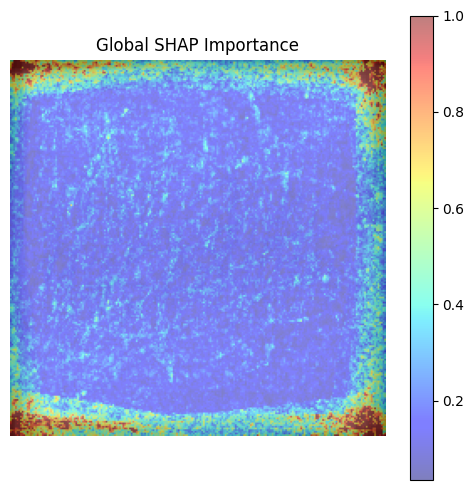

In [46]:
# compute global SHAP using 50 test images

# =========================
# GLOBAL SHAP
# =========================

num_samples = 50

shap_maps = []

# loop over data
model.eval()

for i, (img, label) in enumerate(test_loader):

    if i >= num_samples:
        break

    img = img[0].unsqueeze(0).to(device)  # batch size = 1

    # forward pass to get prediction
    with torch.no_grad():
        output = model(img)
        pred = output.argmax(dim=1).item()

    # SHAP
    shap_values = shap_explainer.shap_values(img, ranked_outputs=1)
    shap_img = shap_values[0][0]

    # to numpy
    if torch.is_tensor(shap_img):
        shap_img = shap_img.cpu().numpy()

    # aggregate channels
    shap_img = np.mean(np.abs(shap_img), axis=0)

    # store SHAP for each image
    shap_maps.append(shap_img)

# -------------------------
# GLOBAL AGGREGATION
# -------------------------
global_shap = np.median(shap_maps, axis=0)

# normalize
global_shap = normalize_map(global_shap)

# -------------------------
# VISUALIZATION
# -------------------------
mean_img = background.mean(dim=0).cpu().numpy()
mean_img = np.mean(mean_img, axis=0)

plt.figure(figsize=(5,5))
plt.imshow(mean_img, cmap="gray")
plt.imshow(global_shap, cmap="jet", alpha=0.5)
plt.title("Global SHAP Importance")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

The Global SHAP map highlights higher importance near image borders, while the central region containing the signature shows lower attribution. This suggests that SHAP partially attributes model decisions to background or framing information.


However, SHAP GradientExplainer is gradient-based and may produce smoothed attribution patterns influenced by background selection. Therefore, this result should be interpreted cautiously and validated against other explainability methods.

### Global GradCAM

(-0.5, 223.5, 223.5, -0.5)

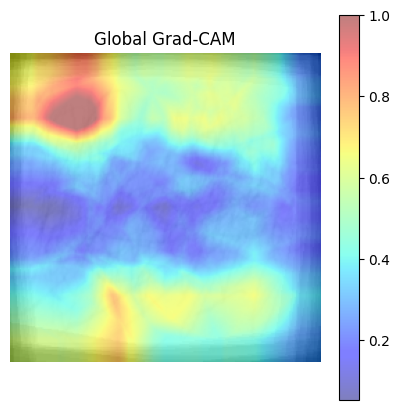

In [47]:
# =========================
# GLOBAL GRADCAM
# =========================

gradcam_maps = []

model.eval()

for i, (img, label) in enumerate(test_loader):

    if i >= num_samples:
        break

    input_tensor = img[0].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred = output.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(pred)]

    cam_map = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    gradcam_maps.append(cam_map)

# aggregate
global_gradcam = np.median(gradcam_maps, axis=0)
global_gradcam = normalize_map(global_gradcam)

plt.figure(figsize=(5,5))
plt.imshow(mean_img, cmap="gray")
plt.imshow(global_gradcam, cmap="jet", alpha=0.5)
plt.title("Global Grad-CAM")
plt.colorbar()
plt.axis("off")

The Global Grad-CAM map shows higher importance in localized regions within the central-left portion of the image, particularly in the upper-left and lower-left areas. This suggests that the model relies on spatially coherent regions aligned with typical signature placement rather than background borders.

Compared to Global SHAP, Grad-CAM provides more focused and spatially consistent attribution, offering a more reliable indication of the areas that influence the model’s predictions.

## Explainable System - Decision Tree

In this section, a fully interpretable classification system is built using handcrafted features extracted from signature images.

Instead of deep learned representations, the model relies on measurable structural properties of the handwriting, such as stroke thickness, curvature, pixel density, and aspect ratio. These features are used to train a shallow Decision Tree classifier, which produces transparent decision rules for distinguishing genuine and forged signatures. The resulting model allows direct interpretation of predictions and provides a comparison between a fully explainable system and the deep learning approach.

The function below extracts interpretable features from each signature image:

- **Thickness**: stroke width
- **Curvature**: smoothness vs shaky writing
- **Pixel density**: amount of ink
- **Aspect ratio**: signature shape

These features are directly interpretable and can be used by a transparent classifier (Decision Tree) to produce human-readable decision rules for genuine vs forged signatures.

In [48]:
# Feature Extraction Function
def extract_features(img_tensor):

    # convert from tensor to numpy grayscale
    # input tensor shape: [C, H, W]
    # convert to [H, W, C] and denormalize
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img * 0.5) + 0.5  # denormalize
    img = np.clip(img, 0, 1)
    # convert to grayscale uint8 image [0–255]
    img = (img[:,:,0] * 255).astype(np.uint8)

    # -------------------------
    # 1. BINARIZATION
    # -------------------------
    # Convert to binary image:
    # signature strokes → white (255)
    # background → black (0)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    # -------------------------
    # 2. THICKNESS
    # -------------------------
    # Distance transform measures distance from stroke center
    # Larger values → thicker strokes
    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    thickness = np.mean(dist[dist > 0]) * 2 if np.any(dist > 0) else 0

    # -------------------------
    # 3. SKELETON
    # -------------------------
    # Reduce signature to 1-pixel wide skeleton
    # used to analyze writing structure
    skeleton = skeletonize(binary // 255)
    # coordinates of skeleton pixels
    coords = np.column_stack(np.where(skeleton > 0))
    # sort coordinates to ensure deterministic curvature computation
    coords = coords[np.lexsort((coords[:,1], coords[:,0]))]

    # -------------------------
    # 4. CURVATURE
    # -------------------------
    # Compute angle changes along skeleton
    # high curvature → irregular / shaky strokes
    # low curvature → smooth handwriting
    curvatures = []
    for i in range(1, len(coords)-1):
        p1, p2, p3 = coords[i-1], coords[i], coords[i+1]

        v1 = p2 - p1
        v2 = p3 - p2

        denom = (np.linalg.norm(v1)*np.linalg.norm(v2) + 1e-8)
        angle = np.arccos(np.clip(np.dot(v1, v2)/denom, -1, 1))

        curvatures.append(angle)
    # average curvature across signature
    avg_curvature = np.mean(curvatures) if len(curvatures) > 0 else 0

    # -------------------------
    # 5. PIXEL DENSITY
    # -------------------------
    # proportion of ink pixels
    # higher → more filled signature
    density = np.sum(binary > 0) / binary.size

    # -------------------------
    # 6. ASPECT RATIO
    # -------------------------
    # width / height of signature image
    # captures overall signature proportions
    h, w = binary.shape
    aspect_ratio = w / h

    return [thickness, avg_curvature, density, aspect_ratio]

In [49]:
# Build Dataset
X_train, y_train = [], []
X_test, y_test = [], []

# TRAIN
for img, label in train_dataset:
    feats = extract_features(img)
    X_train.append(feats)
    y_train.append(label)

# TEST
for img, label in test_dataset:
    feats = extract_features(img)
    X_test.append(feats)
    y_test.append(label)

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [50]:
# Train Explainable Model
clf = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10
)

clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [51]:
# Evaluate
preds = clf.predict(X_test)

acc = accuracy_score(y_test, preds)
print(f"Explainable Model Accuracy: {acc:.2f}")

Explainable Model Accuracy: 0.59


The explainable model achieves an accuracy of ~59%, which is expected because:

- handcrafted features are simple
- signatures require fine-grained patterns
- deep CNN captures spatial relationships
- decision tree uses only 4 global stats to summarize the entire image

In [53]:
# Feature Importance
feature_names = ["thickness", "curvature", "density", "aspect_ratio"]

for name, imp in zip(feature_names, clf.feature_importances_):
    print(f"{name}: {imp:.3f}")

thickness: 0.075
curvature: 0.632
density: 0.293
aspect_ratio: 0.000


The decision tree relies mainly on curvature, which is the most important feature, followed by pixel density as a secondary contributor. Thickness has a minor impact, while aspect ratio is not used by the model.

This indicates that the model distinguishes signatures primarily based on stroke smoothness and irregularity (curvature), along with the overall amount of ink (density), while stroke width (thickness) plays a smaller role and global shape (aspect ratio) does not contribute to the decision.

In [54]:
# Show Decision Rules
rules = export_text(clf, feature_names=feature_names)
print("\nDecision Tree Rules:\n")
print(rules)


Decision Tree Rules:

|--- curvature <= 0.36
|   |--- curvature <= 0.17
|   |   |--- density <= 0.06
|   |   |   |--- class: 1
|   |   |--- density >  0.06
|   |   |   |--- class: 0
|   |--- curvature >  0.17
|   |   |--- thickness <= 8.74
|   |   |   |--- class: 0
|   |   |--- thickness >  8.74
|   |   |   |--- class: 0
|--- curvature >  0.36
|   |--- curvature <= 1.76
|   |   |--- density <= 0.00
|   |   |   |--- class: 0
|   |   |--- density >  0.00
|   |   |   |--- class: 1
|   |--- curvature >  1.76
|   |   |--- density <= 0.15
|   |   |   |--- class: 0
|   |   |--- density >  0.15
|   |   |   |--- class: 0



In [55]:
# Explain one prediction
idx = 0  # pick a sample

print("\nExample prediction")
print("Features:", X_test[idx])
print("Prediction:", preds[idx])
print("True:", y_test[idx])


Example prediction
Features: [2.00264025 1.68688692 0.00603874 1.        ]
Prediction: 1
True: 0


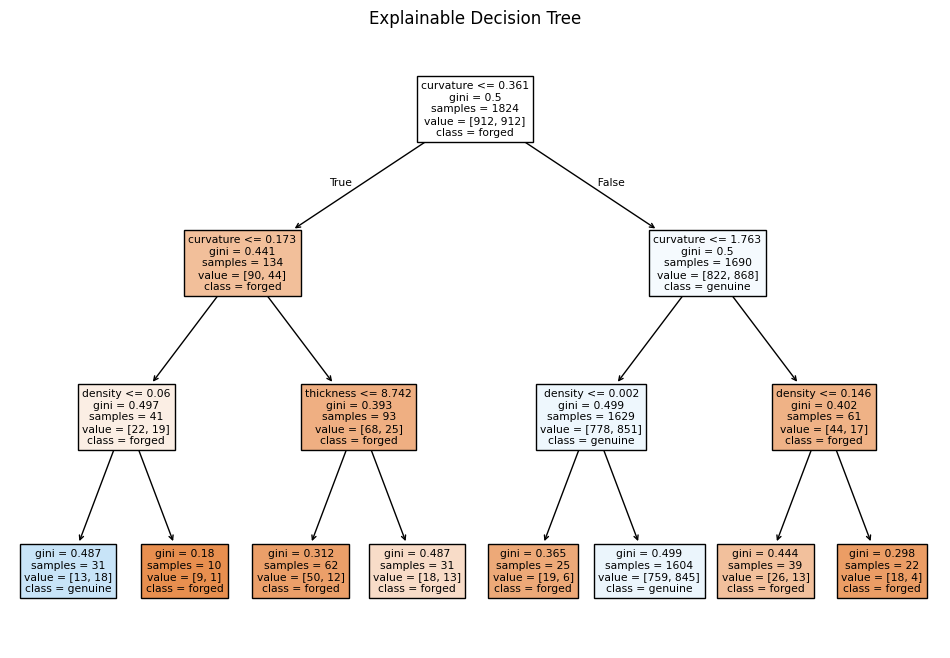

In [56]:
# Visual Tree
plt.figure(figsize=(12,8))
tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=["forged","genuine"],
    filled=True
)

plt.title("Explainable Decision Tree")
plt.show()

**Decision Tree**

The explainable decision tree relies primarily on curvature, with pixel density as a secondary feature and thickness contributing only marginally. The root split is based on curvature, indicating that stroke smoothness and irregularity are the main criteria used to distinguish genuine and forged signatures, with density further refining some decisions.

The model bases its predictions on interpretable structural characteristics of the signatures, but performance remains limited. The explainable system achieves 59% test accuracy, compared to 94.9% for the DenseNet model.
This highlights the trade-off between interpretability and performance: while the decision tree provides transparent and human-readable rules, it cannot capture the complex spatial patterns learned by the deep learning model.

# Conclusion

This project demonstrates how Explainable AI can be applied to signature verification in a banking context, balancing predictive performance with transparency. A DenseNet-based deep learning model achieved strong performance (94.9% test accuracy), successfully distinguishing genuine and forged signatures while maintaining good generalization. Local explainability methods (LIME, Grad-CAM, Integrated Gradients, Occlusion, and SHAP) showed that the model primarily relies on meaningful stroke regions and structural handwriting patterns, confirming that predictions are based on relevant features rather than noise. Global explanations further indicated that Grad-CAM provides more consistent and reliable attribution compared to SHAP.

To complement the deep model, a fully interpretable Decision Tree was built using handcrafted features such as curvature, density, thickness, and aspect ratio. This explainable system achieved lower performance (59% accuracy) but provided transparent decision rules, highlighting curvature and pixel density as the most informative features. The comparison illustrates the trade-off between interpretability and accuracy: deep learning offers superior performance, while interpretable models provide full transparency.